original shape: torch.Size([8, 3, 64, 64])
size after convolution layer: torch.Size([8, 16, 64, 64])
size after pooling: torch.Size([8, 16, 32, 32])


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


torch.Size([1, 3])
CNN(
  (conv_layer): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)
total parameters: 1,054,179
<class 'torch.Tensor'>
[[-0.08949919  0.01958134 -0.00869245]]
maximum accuray: epoch:27 max accuracy: 0.5454545454545454


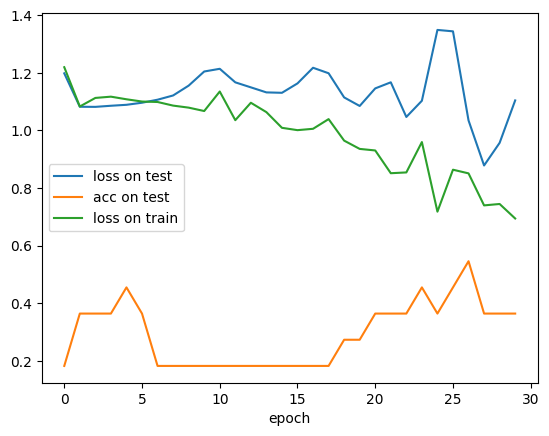

[[2 2 3]
 [0 2 2]
 [0 0 0]]


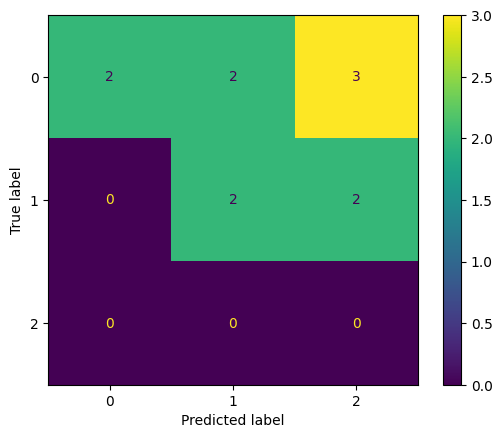

conv_layer.0.weight (16, 3, 3, 3)
conv_layer.0.bias (16,)
conv_layer.3.weight (32, 16, 3, 3)
conv_layer.3.bias (32,)
classifier.1.weight (128, 8192)
classifier.1.bias (128,)
classifier.3.weight (3, 128)
classifier.3.bias (3,)


In [20]:
import torch.nn as neural_network
convnet=neural_network.Conv2d(in_channels=3, # input=3(R,G,B)
                              kernel_size=3,# every feature map is 3X3
                              padding=1,# border of zeros
                              out_channels=16)# total output maps(no. of feature maps)
'''W_out = floor((W_in + 2*padding - kernel_size) / stride) + 1'''
import torch
a=torch.randn(8,3,64,64)
print('original shape:',a.shape)
x=convnet(a)
print('size after convolution layer:',x.shape)  #[8, 16, 64, 64] as expected 3-->16
pooling_layer=neural_network.MaxPool2d(kernel_size=2,stride=2)
x=pooling_layer(x)
print('size after pooling:',x.shape)
''' [8,3,64,64]------->[8,16,64,64]------->[8,16,32,32]
              convlution            max pooling layer
              layer                   '''

import pandas as pd
import os
from pathlib import Path
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
# from google.colab import drive
# drive.mount('/content/drive')

RAW_ROOT=Path("/content/drive/MyDrive/raw_ml_astro")
IMAGES_DIR=RAW_ROOT/"images_gz2"
DATA_ROOT=Path("/content/drive/MyDrive/please")

def high_level_label(gz2_class: str):
    """Collapse detailed GZ2 morphology codes to a few training buckets."""
    if not gz2_class or gz2_class == "A":
        return None  # artifact / ambiguous — skip
    if gz2_class.startswith("E"):
        return "elliptical"
    if gz2_class.startswith("SB"):
        return "spiral_barred"
    if gz2_class.startswith("S"):
        return "spiral"
    return None

import shutil

shutil.rmtree(DATA_ROOT, ignore_errors=True)
def build_imagefolder_layout(
    images_dir,
    mapping_csv,
    labels_csv,
    out_root,
    per_class=200,
    seed=42,
):
    """Symlink a balanced subset into out_root// for ImageFolder."""
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv).rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"])

    images_dir = Path(images_dir)
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    counts = {}
    for label in sorted(df["label"].unique()):
        class_dir = out_root / label
        class_dir.mkdir(exist_ok=True)
        rows = df[df["label"] == label]
        # print(df["label"].value_counts(dropna=False))

        if len(rows) > per_class:
            rows = rows.sample(n=per_class, random_state=seed)
        linked = 0
        for _, row in rows.iterrows():
            src = images_dir / f"{int(row.asset_id)}.jpg"
            dst = class_dir / f"{int(row.asset_id)}.jpg"
            if src.exists() and not dst.exists():
              shutil.copy2(src, dst)
              linked += 1
        counts[label] = linked
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    # print("After merge:", len(df))
    # print(df["gz2_class"].head(20))
    # print(os.listdir(images_dir)[:10])
    # print(os.listdir(IMAGES_DIR)[:20])

    return counts

PER_CLASS = 200
counts = build_imagefolder_layout(
    IMAGES_DIR,
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
    DATA_ROOT,
    per_class=PER_CLASS,
)

trans=transforms.Compose([transforms.Resize((64,64)),transforms.ToTensor(),transforms.Normalize([0.5]*3,[0.5]*3)])
data=datasets.ImageFolder(root=DATA_ROOT,transform=trans)
image,label=data[0]
train_size = int(0.8 * len(data))
test_size = len(data) - train_size
from torch.utils.data import random_split
train_dataset, test_dataset = random_split(
    data,
    [train_size, test_size]
)

trainer=DataLoader(train_dataset,batch_size=32,shuffle=True,num_workers=2, pin_memory=True)
tester=DataLoader(test_dataset,batch_size=32,shuffle=False,num_workers=2, pin_memory=True)





images_file,label_file=next(iter(trainer))
from torch.nn import Module 
from torch.optim import Adam
from torch.nn import CrossEntropyLoss
import matplotlib.pyplot as plt
# actual model

# conv_layer_1=neural_network.Conv2d(in_channels=3,out_channels=16,kernel_size=3,padding=1)
# max_pool_layer_1=neural_network.MaxPool2d(kernel_size=2,stride=2)
# conv_layer_2=neural_network.Conv2d(in_channels=16,out_channels=32,kernel_size=3,padding=1)
# max_pool_layer_2=neural_network.MaxPool2d(kernel_size=2,stride=2)



class CNN(Module):
    def __init__(self,output_classes):
        super().__init__()
        self.conv_layer = neural_network.Sequential(
            neural_network.Conv2d(3,16,3,padding=1),
            neural_network.ReLU(),
            neural_network.MaxPool2d(2,2),

            neural_network.Conv2d(16,32,3,padding=1),
            neural_network.ReLU(),
            neural_network.MaxPool2d(2,2)
        )
        self.classifier=neural_network.Sequential(
            neural_network.Flatten(),
            neural_network.Linear(32*16*16,128),
            neural_network.ReLU(),
            neural_network.Linear(128,output_classes)
        )
    

    def forward(self,x):
        x=self.conv_layer(x)
        x=self.classifier(x)
        return x
    
    


@torch.no_grad()
def evaluate(model,dataset,loss_method):
    model.eval()
    # model.to('cuda')
    loss_on_data,total,correct=0,0,0
    for im,la in dataset:
        # im,la=im.to('cuda'),la.to('cuda')
        out=model(im)
        loss=loss_method(out,la)
        loss_on_data+=loss.item()*im.size(0)
        preds = out.argmax(dim=1)              # predicted class = biggest logit
        correct += (preds == la).sum().item()
        total += la.size(0)
    avg_loss=loss_on_data/total
    acc=correct/total
    return avg_loss,acc






def train(dataset,epochs,model,loss_method):
    
    error=[]
    # model.to('cuda')
    val_a,val_l=[],[]
    for i in range(epochs):
        e,c=0,0
        for im ,la in dataset:
            # im, la = im.to('cuda'), la.to('cuda')
            optimize.zero_grad()
            out=model(im)
            loss=loss_method(out,la)
            loss.backward()
            optimize.step()
            e+=loss.item()
            c+=1
        error.append(e/c)
        val_loss, val_acc = evaluate(model, tester, loss_method)
        val_l.append(val_loss)
        val_a.append(val_acc)
    print('maximum accuray:',f"epoch:{val_a.index(max(val_a))+1}",'max accuracy:',max(val_a))
    
    plt.plot(val_l,label='loss on test')
    plt.plot(val_a,label='acc on test')
    plt.plot(error,label='loss on train')
    plt.xlabel('epoch')
    plt.legend()
    plt.show()


import numpy as np

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
def confu(data,model):
    predicted,truth=[],[]
    for im,la in data:
        out=model(im)
        pred=out.argmax(dim=1)
        predicted.append(pred)
        truth.append(la)


    predicted,truth= torch.cat(predicted).numpy(),torch.cat(truth).numpy()
    cm=confusion_matrix(predicted,truth)
    print(cm)
    disp=ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.show()

model=CNN(3) 
a=torch.rand(1,3,64,64)
logit=model(a)
print(logit.shape)
print(model)
total = sum(p.numel() for p in model.parameters())
print(f"total parameters: {total:,}") #1,054,179
print(type(logit))
w=logit.detach().numpy()
print(w)

optimize=Adam(model.parameters(),1e-3)
loss_method=CrossEntropyLoss()



train(dataset=trainer,model=model,epochs=30,loss_method=loss_method)
avg_loss,accuracy=evaluate(model,trainer,loss_method)
confu(tester,model)
# print('avgerage loss on data:',avg_loss)
# print('accuracy on data:',accuracy)

# features.0.weight (16, 3, 3, 3)
# features.0.bias   (16,)
# features.3.weight (32, 16, 3, 3)
# ...
# classifier.1.weight (128, 8192)
# classifier.3.weight (3, 128)
# cor,c=0,0
# for im, la in tester:
#     out=model(im)
#     out=out.detach().numpy()
#     print(im.shape)
#     print(la.shape)
#     print(la)
#     print(out)
#     if np.argmax(out)==la.detach().numpy()[c]:
#         cor+=1
#     c+=1
# print(cor/c)
for name, tensor in model.state_dict().items():
    print(name, tuple(tensor.shape))





In [21]:
torch.save(model.state_dict(),'/content/drive/MyDrive/model_on_astronomy.pth')
